In [1]:
import pandas as pd
df_2 = pd.read_csv("preprocessed_adult_income.csv")

df_2.head()


,age,educational-num,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,7,0,0,40,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,38,9,0,0,50,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,28,12,0,0,40,1,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,10,7688,0,40,1,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,18,10,0,0,30,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [2]:
# Importing necessary libraries and loading models
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load preprocessed dataset
df_2 = pd.read_csv("preprocessed_adult_income.csv")

# Split into features (X) and target (y)
X = df_2.drop('income', axis=1)
y = df_2['income']


In [3]:
# Train-validation-test split (70% train, 15% validation, 15% test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Standardize features to get better neural network performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [11]:
# Building Model with L2 Regularization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.regularizers import l2

# Define the model with L2 regularization on both hidden layers
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss=BinaryCrossentropy(),
              metrics=['accuracy'])


In [15]:
# Train with Early Stopping
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train_scaled, y_train,
                    validation_data=(X_val_scaled, y_val),
                    epochs=100,              # Higher epochs, early stopping will stop earlier if needed
                    batch_size=64,
                    callbacks=[early_stop],
                    verbose=1)


Epoch 1/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8450 - loss: 0.3506 - val_accuracy: 0.8546 - val_loss: 0.3345
Epoch 2/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8419 - loss: 0.3573 - val_accuracy: 0.8546 - val_loss: 0.3376
Epoch 3/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8455 - loss: 0.3497 - val_accuracy: 0.8559 - val_loss: 0.3355
Epoch 4/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8474 - loss: 0.3423 - val_accuracy: 0.8572 - val_loss: 0.3344
Epoch 5/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8468 - loss: 0.3472 - val_accuracy: 0.8578 - val_loss: 0.3317
Epoch 6/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8461 - loss: 0.3513 - val_accuracy: 0.8565 - val_loss: 0.3332
Epoch 7/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8516 - loss: 0.3442 - val_accuracy: 0.8563 - val_loss: 0.3328
Epoch 8/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8482 - loss: 0.3470 - val_accu

In [16]:
#Evaluating the Model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predict on test data
y_pred_probs = model.predict(X_test_scaled)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# Evaluation results
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_classes))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))
print("\nClassification Report:\n", classification_report(y_test, y_pred_classes, target_names=['<=50K', '>50K']))



229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Neural Network Accuracy: 0.8502797870888494

Confusion Matrix:
 [[5123  451]
 [ 646 1107]]

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      5574
        >50K       0.71      0.63      0.67      1753

    accuracy                           0.85      7327
   macro avg       0.80      0.78      0.79      7327
weighted avg       0.85      0.85      0.85      7327



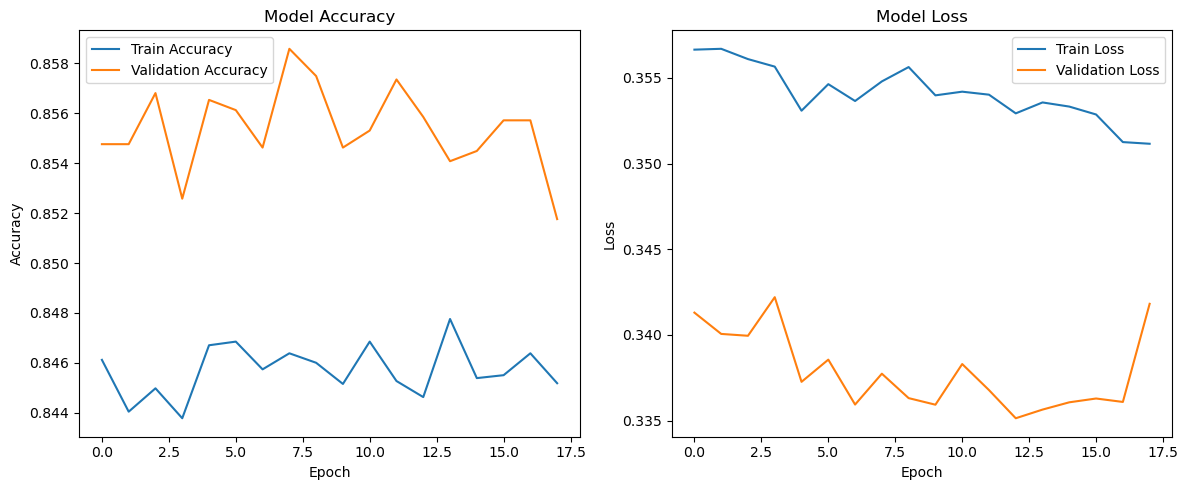

In [9]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


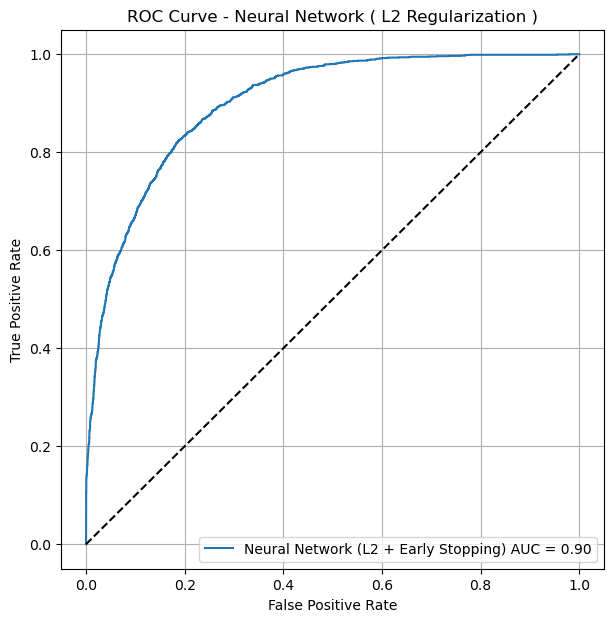

ROC AUC Score: 0.9019


In [18]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predict probabilities for the positive class
nn_probs = model.predict(X_test_scaled).ravel()

# Calculate AUC score
nn_auc = roc_auc_score(y_test, nn_probs)

# Get FPR, TPR for ROC curve
fpr, tpr, _ = roc_curve(y_test, nn_probs)

# Plot ROC curve
plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, label=f"Neural Network (L2 + Early Stopping) AUC = {nn_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guess
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Neural Network ( L2 Regularization )")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"ROC AUC Score: {nn_auc:.4f}")


229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


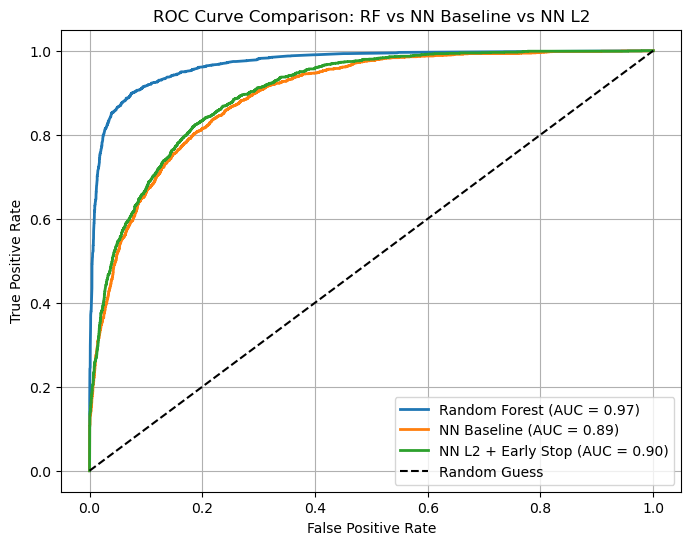

ROC comparison plot saved to: C:\Users\hp\roc_curve_comparison_3_models.png


In [23]:
# Comparing The ROC Curve of final 3 models
import joblib
from tensorflow.keras.models import load_model
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import os

# --- Load Saved Models ---
rf_model = joblib.load("random_forest_model.best")
nn_baseline_model = load_model("nn_baseline_model.h5")
# nn_l2_model = model  # Your current L2 + early stopping model already in memory

# --- Random Forest ---
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# --- Neural Network Baseline ---
nn_baseline_probs = nn_baseline_model.predict(X_test_scaled).ravel()
nn_baseline_auc = roc_auc_score(y_test, nn_baseline_probs)
nn_baseline_fpr, nn_baseline_tpr, _ = roc_curve(y_test, nn_baseline_probs)

# --- Neural Network L2 + Early Stopping (current model) ---
nn_l2_probs = model.predict(X_test_scaled).ravel()
nn_l2_auc = roc_auc_score(y_test, nn_l2_probs)
nn_l2_fpr, nn_l2_tpr, _ = roc_curve(y_test, nn_l2_probs)

# --- Plot ROC Curves ---
plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})", linewidth=2)
plt.plot(nn_baseline_fpr, nn_baseline_tpr, label=f"NN Baseline (AUC = {nn_baseline_auc:.2f})", linewidth=2)
plt.plot(nn_l2_fpr, nn_l2_tpr, label=f"NN L2 + Early Stop (AUC = {nn_l2_auc:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: RF vs NN Baseline vs NN L2")
plt.legend(loc="lower right")
plt.grid(True)

# --- Save Plot ---
save_path = os.path.join(os.getcwd(), "roc_curve_comparison_3_models.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"ROC comparison plot saved to: {save_path}")
